# imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import arff
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler


# Load dataset

In [ ]:
file_name = "Rice_Cammeo_Osmancik.arff"
data, meta = arff.loadarff(file_name)
df = pd.DataFrame(data)

Five samples from each class were examined to ensure data correctness.

In [ ]:
df = pd.DataFrame(data)

# Data clean
if df['Class'].dtype == object:
    df['Class'] = df['Class'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
df['Convex_Area_Ratio'] = df['Convex_Area'] / df['Area']
print("\nFirst 5 Rows of the Dataset")
print(df.head())
print("-" * 60 + "\n")


First 5 Rows of the Dataset
      Area   Perimeter  Major_Axis_Length  Minor_Axis_Length  Eccentricity  \
0  15231.0  525.578979         229.749878          85.093788      0.928882   
1  14656.0  494.311005         206.020065          91.730972      0.895405   
2  14634.0  501.122009         214.106781          87.768288      0.912118   
3  13176.0  458.342987         193.337387          87.448395      0.891861   
4  14688.0  507.166992         211.743378          89.312454      0.906691   

   Convex_Area    Extent   Class  Convex_Area_Ratio  
0      15617.0  0.572896  Cammeo           1.025343  
1      15072.0  0.615436  Cammeo           1.028384  
2      14954.0  0.693259  Cammeo           1.021867  
3      13368.0  0.640669  Cammeo           1.014572  
4      15262.0  0.646024  Cammeo           1.039080  
------------------------------------------------------------



# Data Preprocessing

Encode class labels

In [ ]:
# Encode class labels
le = LabelEncoder()
df["Class"] = le.fit_transform(df["Class"])

# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

Split the dataset into train / validation / test sets

In [ ]:
# 60% train, 40% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

# Split temporary set into 20% validation and 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

Feature scaling

KNN is a distance-based algorithm, so feature scaling is required.

The scaler is fitted on the training set only to avoid data leakage.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Display the first 5 rows of the scaled training data
feature_names = X_train.columns
scaled_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)

print("First 5 rows of scaled training data:")
print(scaled_train_df.head())

First 5 rows of scaled training data:
       Area  Perimeter  Major_Axis_Length  Minor_Axis_Length  Eccentricity  \
0  2.020158   1.914536           1.883795           1.331894      0.916951   
1  0.082795   0.146476           0.086872           0.177677      0.080880   
2  0.443235   0.603390           0.640872           0.033531      0.706962   
3  0.675441   1.074463           1.036448           0.102713      0.989868   
4  0.253195   0.171415           0.206278           0.215898      0.175637   

   Convex_Area    Extent  Convex_Area_Ratio  
0     2.068642 -0.775913           0.943968  
1     0.113733 -0.085787           0.677612  
2     0.478026 -0.755450           0.749310  
3     0.798401  0.079960           2.498091  
4     0.343457  1.570497           1.921030  


Check three dataset

In [ ]:
print("Training set shape:", X_train_scaled.shape)
print("Validation set shape:", X_val_scaled.shape)
print("Test set shape:", X_test_scaled.shape)

Training set shape: (2286, 8)
Validation set shape: (762, 8)
Test set shape: (762, 8)


# Train a baseline KNN model (k = 5)

In [ ]:
k = 5

knn = KNeighborsClassifier(
    n_neighbors=k,
    weights="uniform",
    metric="minkowski",
    p=2  # Euclidean distance
)

# Train the model
knn.fit(X_train_scaled, y_train)

# Predict on training set
y_train_pred = knn.predict(X_train_scaled)

# Training accuracy
train_acc = accuracy_score(y_train, y_train_pred)
print(f"k = {k}, accuracy on training set: {train_acc:.3f}")

# Confusion matrix (training set)
print("\nConfusion matrix on training set (rows = true, cols = predicted):")
print(confusion_matrix(y_train, y_train_pred))

# Classification report (training set)
print("\nClassification report (training set):")
print(classification_report(y_train, y_train_pred, target_names=le.classes_))

k = 5, accuracy on training set: 0.939

Confusion matrix on training set (rows = true, cols = predicted):
[[ 904   74]
 [  65 1243]]

Classification report (training set):
              precision    recall  f1-score   support

      Cammeo       0.93      0.92      0.93       978
    Osmancik       0.94      0.95      0.95      1308

    accuracy                           0.94      2286
   macro avg       0.94      0.94      0.94      2286
weighted avg       0.94      0.94      0.94      2286



# Find best k use validation dataset

In [ ]:
k_values = range(1, 21, 2)   # odd k values: 1, 3, 5, ..., 19
val_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(
        n_neighbors=k,
        weights="uniform",
        metric="minkowski",
        p=2   # Euclidean distance
    )

    # Train on training set
    model.fit(X_train_scaled, y_train)

    # Evaluate on validation set
    y_val_pred = model.predict(X_val_scaled)
    acc = accuracy_score(y_val, y_val_pred)
    val_accuracies.append(acc)

# Print results
for k, acc in zip(k_values, val_accuracies):
    print(f"k = {k:2d} -> validation accuracy = {acc:.3f}")

k =  1 -> validation accuracy = 0.886
k =  3 -> validation accuracy = 0.906
k =  5 -> validation accuracy = 0.920
k =  7 -> validation accuracy = 0.915
k =  9 -> validation accuracy = 0.915
k = 11 -> validation accuracy = 0.920
k = 13 -> validation accuracy = 0.915
k = 15 -> validation accuracy = 0.912
k = 17 -> validation accuracy = 0.908
k = 19 -> validation accuracy = 0.908


Validation accuracy vs k

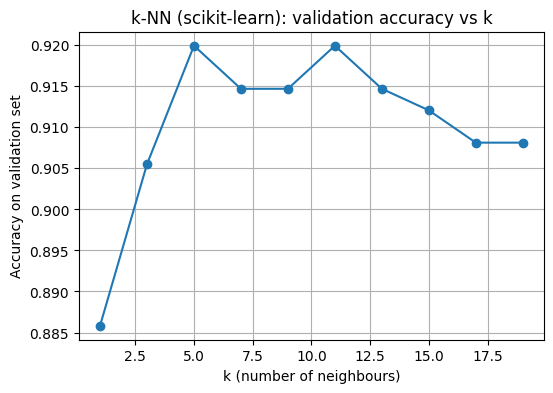

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(list(k_values), val_accuracies, marker='o')
plt.xlabel("k (number of neighbours)")
plt.ylabel("Accuracy on validation set")
plt.title("k-NN (scikit-learn): validation accuracy vs k")
plt.grid(True)
plt.show()

In [ ]:
best_k = k_values[val_accuracies.index(max(val_accuracies))]
best_val_acc = max(val_accuracies)

print(f"\nBest k based on validation set: {best_k}")
print(f"Best validation accuracy: {best_val_acc:.3f}")



Best k based on validation set: 5
Best validation accuracy: 0.920


# Train with best_k and evaluate on the test set

In [ ]:
# 1) Get best k from validation results
best_k = k_values[val_accuracies.index(max(val_accuracies))]
print(f"Best k selected from validation set: {best_k}")

# 2) Train the final model on the training set
final_knn = KNeighborsClassifier(
    n_neighbors=best_k,
    weights="uniform",
    metric="minkowski",
    p=2  # Euclidean distance
)
final_knn.fit(X_train_scaled, y_train)

# 3) Evaluate on the test set (only once)
y_test_pred = final_knn.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_test_pred)
print(f"\nFinal test accuracy (k = {best_k}): {test_acc:.3f}")

print("\nConfusion matrix on test set (rows = true, cols = predicted):")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification report (test set):")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

Best k selected from validation set: 5

Final test accuracy (k = 5): 0.933

Confusion matrix on test set (rows = true, cols = predicted):
[[292  34]
 [ 17 419]]

Classification report (test set):
              precision    recall  f1-score   support

      Cammeo       0.94      0.90      0.92       326
    Osmancik       0.92      0.96      0.94       436

    accuracy                           0.93       762
   macro avg       0.93      0.93      0.93       762
weighted avg       0.93      0.93      0.93       762



# Plot the Confusion Matrix (Test Set)

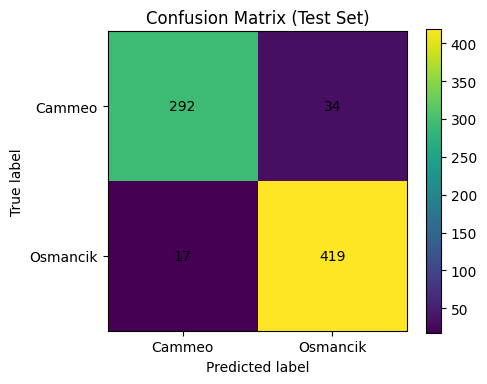

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.colorbar()

# Axis labels
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix (Test Set)")

# Tick labels (class names)
class_names = le.classes_
plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

# Annotate each cell with the count
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.tight_layout()
plt.show()

# A summary table for Train / Validation / Test results

In [ ]:
results_df = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Test"],
    "Accuracy": [train_acc, best_val_acc, test_acc]
})

# Optional: round for cleaner display
results_df["Accuracy"] = results_df["Accuracy"].round(3)

print("Summary of KNN performance (k = {})".format(best_k))
print(results_df)

Summary of KNN performance (k = 5)
      Dataset  Accuracy
0    Training     0.939
1  Validation     0.920
2        Test     0.933
